# Allows uploading files from local computer into Google Colab

In [ ]:
from google.colab import files

In [ ]:
#import numpy for numerical operations, panda for reading and managing data, matplotlib to create for graph and scatter, Kmeans algorithm and standard scaler for normalize data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
#uploaded dataset file from local device
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv


In [ ]:
#read uplaoded data
df=pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
#check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
#for checking number of rows and columns in dataset
print(df.shape)

(101766, 50)


In [ ]:
#check if there is any missing values are present in the data
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
#replace values in dataset
df = df.replace("?", np.nan)
drop_cols = ['encounter_id', 'patient_nbr', 'payer_code', 'medical_specialty', 'weight']
df = df.drop(columns=drop_cols, errors='ignore')

print(df.shape)

(101766, 45)


Text(0, 0.5, 'Number of Medications')

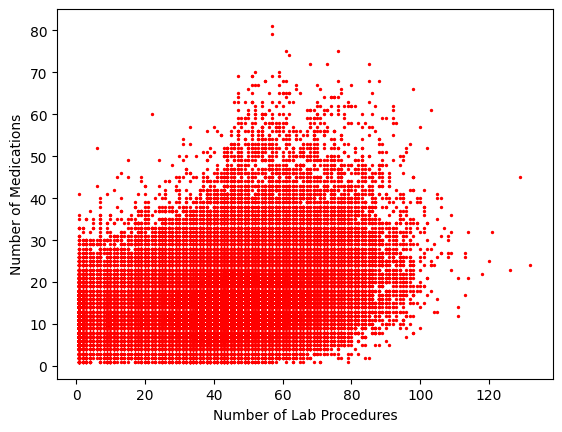

In [ ]:
#scatter plot
#create a scatter plot showing relationship between lab procedures and medications
# Label X and Y axis

plt.scatter(df['num_lab_procedures'],df['num_medications'], c='red', s=2)
plt.xlabel("Number of Lab Procedures")
plt.ylabel("Number of Medications")

In [ ]:
#set number of cluster to get desirable output

k=2
X=np.array(list(zip(df['num_lab_procedures'], df['num_medications'])))
model=KMeans(n_clusters=k)
kmeans=model.fit(X)
labels=model.predict(X)
centroids=model.cluster_centers_

print(labels)
print(centroids)

[0 1 0 ... 1 1 0]
[[24.75964814 13.77616781]
 [56.43583215 17.65566646]]


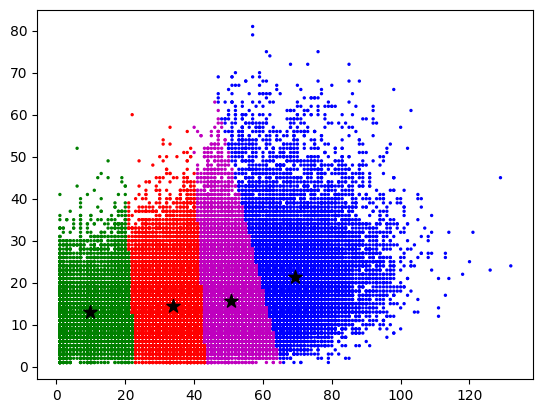

In [ ]:
#Plot the data and centroids on a scatter plot
#map the labels to colors

c=['m','g','b','r','y','c']
colors=[c[i] for i in labels]

plt.scatter(df['num_lab_procedures'], df['num_medications'], c=colors, s=2)
plt.scatter(centroids[:,0], centroids[:,1], marker='*', s=100, c='black')

In [ ]:
#Using the model that you have just trained,
#you can use it to predict what cluster for any data pt

cluster=model.predict([[35,123]])[0]
print(c[cluster])

b


In [ ]:
#To determine the silhouette coefficient/score

from sklearn.metrics import silhouette_score

model=KMeans(n_clusters=2)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=2): {silhouette_score(X,label)}')


model=KMeans(n_clusters=3)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=3): {silhouette_score(X,label)}')


model=KMeans(n_clusters=4)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=4): {silhouette_score(X,label)}')

silhouette Score (n=2): 0.4506531982761403
silhouette Score (n=3): 0.42524501806287635
silhouette Score (n=4): 0.3656606245321629


[[36.55416025 14.94685247]
 [11.00442556 13.09724435]
 [71.00489106 22.93635266]
 [53.91409492 15.41379848]]


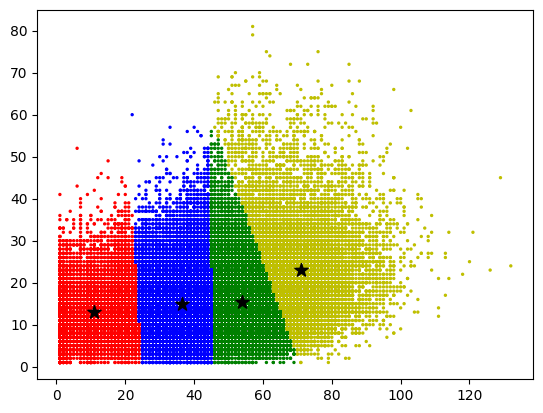

In [ ]:
#Now cluster set to 4 to check the difference
k=4
X=np.array(list(zip(df['num_lab_procedures'],df['num_medications'])))

#create KMeans clustering model

kmeans=KMeans(n_clusters=k)
kmeans=kmeans.fit(X)
labels=kmeans.predict(X)
centroids=kmeans.cluster_centers_

#map the labels to colors
c=['b','r','y','g','c','m']
colors=[c[i] for i in labels]

plt.scatter(df['num_lab_procedures'],df['num_medications'],c=colors,s=2)
plt.scatter(centroids[:,0],centroids[:,1],marker='*',s=100,c='black')

print(centroids)

## This analysis uses a diabetes hospital dataset that contains patient visit information, and for this task we focused on two easy-to-understand measures: the number of lab procedures and the number of medications given during a visit. After cleaning the data by removing IDs and columns that don’t help with patterns, we applied a technique called **K-Means clustering**, which simply groups similar visits together based on how close they are in these two measures. We tested different numbers of groups (called **k**) and used a quality check (silhouette score) to see which grouping made the most sense; the results showed that **k = 4** provided a good balance between clarity and separation of groups. The algorithm automatically placed each hospital visit into one of four clusters and calculated a “center” for each group, which represents a typical visit pattern for that cluster. In practical terms, this means we identified four distinct types of diabetes-related hospital visits, ranging from fewer labs and medications to much more intensive care, helping the business quickly understand different levels of treatment intensity without needing any machine learning background.